# 06b - ResNet50 (VGGFace2) Visualization + AlexNet Comparison

Turns the ResNet50-VGGFace2 baseline accuracy table into a heatmap,
and compares FFA accuracy directly against AlexNet.

In [19]:
!git clone https://github.com/sossyh/ffa-dnn-ablation.git
%cd ffa-dnn-ablation

Cloning into 'ffa-dnn-ablation'...
remote: Enumerating objects: 195, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 195 (delta 103), reused 151 (delta 65), pack-reused 0 (from 0)
Receiving objects: 100% (195/195), 639.54 KiB | 3.38 MiB/s, done.
Resolving deltas: 100% (103/103), done.
/content/ffa-dnn-ablation/ffa-dnn-ablation/ffa-dnn-ablation


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

resnet_df = pd.read_csv("results/tables/resnet_vggface2/baseline_accuracy.csv")
resnet_df.head()

,layer,region,accuracy
0,repeat_1,V1,0.182278
1,repeat_1,V2,0.188335
2,repeat_1,V3,0.160475
3,repeat_1,V4,0.123649
4,repeat_1,LOC,0.168176


## Reshape into a layer x region matrix

In [21]:
layer_order = ["repeat_1", "repeat_2", "repeat_3", "block8", "avgpool_1a"]
region_order = ["V1", "V2", "V3", "V4", "LOC", "EBA", "FFA", "STS", "PPA"]

resnet_pivot = resnet_df.pivot(index="layer", columns="region", values="accuracy")
resnet_pivot = resnet_pivot.reindex(index=layer_order, columns=region_order)
resnet_pivot

region,V1,V2,V3,V4,LOC,EBA,FFA,STS,PPA
layer,,,,,,,,,
repeat_1,0.182278,0.188335,0.160475,0.123649,0.168176,0.169042,0.183660,0.103770,0.129424
repeat_2,0.136759,0.147159,0.134255,0.116567,0.149161,0.150950,0.170713,0.088327,0.115626
repeat_3,0.108088,0.117792,0.109712,0.099068,0.118374,0.112706,0.131060,0.068688,0.100518
block8,0.113422,0.114536,0.099091,0.092478,0.141480,0.139007,0.164580,0.085603,0.105560
avgpool_1a,0.099630,0.094546,0.087681,0.082673,0.144563,0.141593,0.173659,0.087157,0.104666


## Heatmap

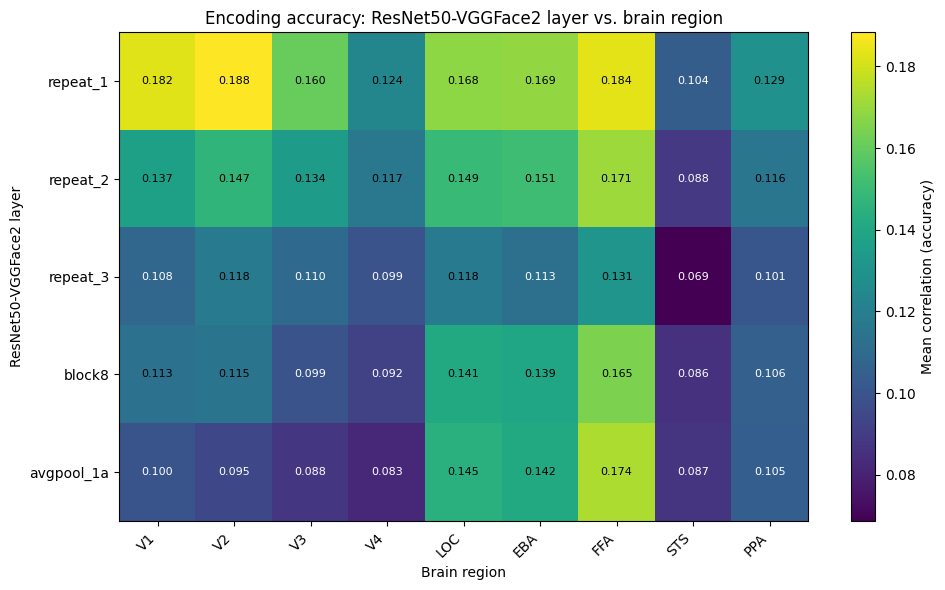

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(resnet_pivot.values, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels(region_order, rotation=45, ha="right")
ax.set_yticks(range(len(layer_order)))
ax.set_yticklabels(layer_order)

ax.set_xlabel("Brain region")
ax.set_ylabel("ResNet50-VGGFace2 layer")
ax.set_title("Encoding accuracy: ResNet50-VGGFace2 layer vs. brain region")

for i in range(len(layer_order)):
    for j in range(len(region_order)):
        val = resnet_pivot.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val < resnet_pivot.values.max() * 0.6 else "black",
                fontsize=8)

fig.colorbar(im, ax=ax, label="Mean correlation (accuracy)")
fig.tight_layout()

os.makedirs("results/figures/resnet_vggface2", exist_ok=True)
fig.savefig("results/figures/resnet_vggface2/layer_region_heatmap.png", dpi=150)
plt.show()

## Best layer per region (ResNet50-VGGFace2)

In [23]:
best_layer_per_region_resnet = resnet_pivot.idxmax(axis=0)
best_accuracy_per_region_resnet = resnet_pivot.max(axis=0)

summary_resnet = pd.DataFrame({
    "best_layer": best_layer_per_region_resnet,
    "best_accuracy": best_accuracy_per_region_resnet,
})
summary_resnet = summary_resnet.reindex(region_order)
print(summary_resnet)

summary_resnet.to_csv("results/tables/resnet_vggface2/best_layer_per_region.csv")

       best_layer  best_accuracy
region                          
V1       repeat_1       0.182278
V2       repeat_1       0.188335
V3       repeat_1       0.160475
V4       repeat_1       0.123649
LOC      repeat_1       0.168176
EBA      repeat_1       0.169042
FFA      repeat_1       0.183660
STS      repeat_1       0.103770
PPA      repeat_1       0.129424


## Side-by-side comparison with AlexNet

Requires `results/tables/alexnet/baseline_accuracy2.csv` to already
exist (from the AlexNet baseline notebook).

In [24]:
alexnet_df = pd.read_csv("results/tables/alexnet/baseline_accuracy2.csv")
alexnet_layer_order = ["conv1", "conv2", "conv3", "conv4", "conv5", "fc6", "fc7", "fc8"]

alexnet_pivot = alexnet_df.pivot(index="layer", columns="region", values="accuracy")
alexnet_pivot = alexnet_pivot.reindex(index=alexnet_layer_order, columns=region_order)

alexnet_ffa_best = alexnet_pivot["FFA"].max()
alexnet_ffa_best_layer = alexnet_pivot["FFA"].idxmax()

resnet_ffa_best = resnet_pivot["FFA"].max()
resnet_ffa_best_layer = resnet_pivot["FFA"].idxmax()

print(f"AlexNet best FFA accuracy: {alexnet_ffa_best:.4f} (layer: {alexnet_ffa_best_layer})")
print(f"ResNet50-VGGFace2 best FFA accuracy: {resnet_ffa_best:.4f} (layer: {resnet_ffa_best_layer})")
print(f"\nDifference (AlexNet - ResNet50-VGGFace2): {alexnet_ffa_best - resnet_ffa_best:.4f}")

AlexNet best FFA accuracy: 0.2657 (layer: fc8)
ResNet50-VGGFace2 best FFA accuracy: 0.1837 (layer: repeat_1)

Difference (AlexNet - ResNet50-VGGFace2): 0.0820


## Side-by-side bar chart: best FFA accuracy per model

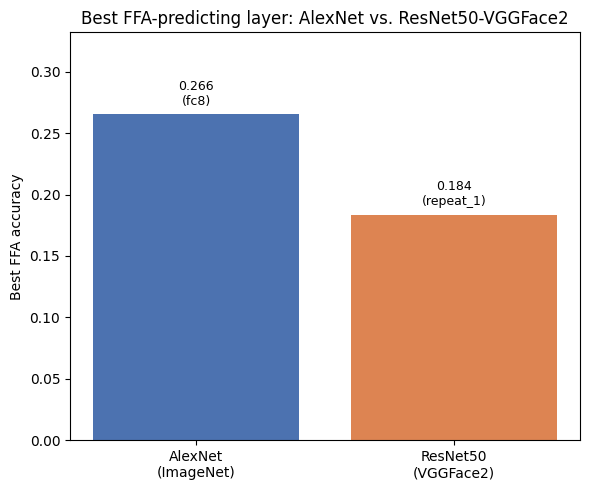

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))

models = ["AlexNet\n(ImageNet)", "ResNet50\n(VGGFace2)"]
best_scores = [alexnet_ffa_best, resnet_ffa_best]
best_layers = [alexnet_ffa_best_layer, resnet_ffa_best_layer]

bars = ax.bar(models, best_scores, color=["#4C72B0", "#DD8452"])

for bar, score, layer in zip(bars, best_scores, best_layers):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.005,
            f"{score:.3f}\n({layer})", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Best FFA accuracy")
ax.set_title("Best FFA-predicting layer: AlexNet vs. ResNet50-VGGFace2")
ax.set_ylim(0, max(best_scores) * 1.25)
fig.tight_layout()

os.makedirs("results/figures/comparison", exist_ok=True)
fig.savefig("results/figures/comparison/alexnet_vs_resnet_ffa.png", dpi=150)
plt.show()

## Full region-by-region comparison table

In [26]:
comparison_rows = []
for region in region_order:
    alexnet_best = alexnet_pivot[region].max()
    alexnet_layer = alexnet_pivot[region].idxmax()
    resnet_best = resnet_pivot[region].max()
    resnet_layer = resnet_pivot[region].idxmax()
    comparison_rows.append({
        "region": region,
        "alexnet_best_accuracy": alexnet_best,
        "alexnet_best_layer": alexnet_layer,
        "resnet_vggface2_best_accuracy": resnet_best,
        "resnet_vggface2_best_layer": resnet_layer,
        "difference (alexnet - resnet)": alexnet_best - resnet_best,
    })

comparison_df = pd.DataFrame(comparison_rows)
os.makedirs("results/tables/comparison", exist_ok=True)
comparison_df.to_csv("results/tables/comparison/alexnet_vs_resnet_all_regions.csv", index=False)
print(comparison_df)

  region  alexnet_best_accuracy alexnet_best_layer  \
0     V1               0.197281              conv4   
1     V2               0.209298              conv4   
2     V3               0.192461              conv5   
3     V4               0.195427                fc6   
4    LOC               0.243977                fc8   
5    EBA               0.246571                fc8   
6    FFA               0.265666                fc8   
7    STS               0.141158                fc7   
8    PPA               0.221483                fc8   

   resnet_vggface2_best_accuracy resnet_vggface2_best_layer  \
0                       0.182278                   repeat_1   
1                       0.188335                   repeat_1   
2                       0.160475                   repeat_1   
3                       0.123649                   repeat_1   
4                       0.168176                   repeat_1   
5                       0.169042                   repeat_1   
6                 

## Download everything

In [27]:
from google.colab import files

files.download("results/figures/resnet_vggface2/layer_region_heatmap.png")
files.download("results/tables/resnet_vggface2/best_layer_per_region.csv")
files.download("results/figures/comparison/alexnet_vs_resnet_ffa.png")
files.download("results/tables/comparison/alexnet_vs_resnet_all_regions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Move the four downloaded files to their matching folders under
`results/`, then commit and push from VS Code.